# Построение модели для детекции глаукомы.

Задачу решу с помощью простой CNN-модели. Нужно решить простую бинарную классификацию - определить, является ли пациент больным глаукомой или нет.

## Импорт нужных модулей и библиотек

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tqdm
import matplotlib.pyplot as plt

#### Создаем новый csv-файл с адресами изображений

In [18]:
df = pd.read_csv("data/Labels.csv")
df["Image Path"] = df["Image Name"].apply(lambda x: f"data/Images/{x}")
df.to_csv("data/Labels_with_path.csv", index=False)

## Разделение данных на test, validation, train датафреймы

##### Берем мах 5 снимков с наибольшим качеством.

In [19]:
def filter_best_images(df, max_images=5):
    df_sorted = df.sort_values(["Patient", "Quality Score"], ascending=[True, False])
    df_filtered = df_sorted.groupby("Patient").head(max_images).reset_index(drop=True)
    return df_filtered

df = filter_best_images(df, max_images=5)

##### Разделение на train, validation, test df.

In [20]:
def patient_split(df, test_size=0.2, val_size=0.1, random_state=2006):
    patients = df["Patient"].unique()
    patient_labels = df.groupby("Patient")["Label"].first().values

    # Splitting for train and other patients.
    train_patients, temp_patients = train_test_split(
        patients,
        test_size=test_size + val_size,
        stratify=patient_labels,
        random_state=random_state
    )

    # Splitting for validation and test.
    temp_labels = df[df["Patient"].isin(temp_patients)].groupby("Patient")["Label"].first().values
    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=test_size / (test_size + val_size),
        stratify=temp_labels,
        random_state=random_state
    )

    # Creating dataframes.
    train_df = df[df["Patient"].isin(train_patients)]
    val_df = df[df["Patient"].isin(val_patients)]
    test_df = df[df["Patient"].isin(test_patients)]

    return train_df, val_df, test_df

In [21]:
train_df, val_df, test_df = patient_split(df)

## GlaucomaDataset для формирования датасета и загрузки изображений

In [22]:
class GlaucomaDataset(Dataset):
    def __init__(self, df, img_dir="data/Images", transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        obj = self.df.iloc[idx]
        img_path = f"{obj["Image Path"]}"
        image = Image.open(img_path)
        target = 1 if obj["Label"] == "GON+" else 0

        if self.transform:
            image_transformed = self.transform(image)

        return image_transformed, target


## Определяем трансформации для изображений

In [23]:
TARGET_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((TARGET_SIZE, TARGET_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Формируем рабочие датасеты

In [24]:
train_dataset = GlaucomaDataset(train_df, transform=train_transform)
val_dataset = GlaucomaDataset(val_df, transform=val_transform)
test_dataset = GlaucomaDataset(test_df, transform=val_transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 483
Val samples:   68
Test samples:  143


## Формируем загрузчики данных

In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 16
Val batches:   3
Test batches:  5


w## Класс модели CNN

In [26]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # CNNs
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        # FC NNs
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=2).to(device)
print(f"Model on: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model on: cpu
Parameters: 26,081,026


## Выбор оптимизатора

#### Функция потерь - CrossEntropyLoss

In [28]:
loss_f = nn.CrossEntropyLoss()

#### Оптимизатор - Adam

In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [30]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total

## Обучение модели

In [31]:
epochs = 10
train_losses, val_losses = [], []
val_accs = []

for epoch in range(epochs):
    model.train()
    loss_mean = 0
    lm_count = 0

    train_tqdm = tqdm.tqdm(train_loader, leave=True)
    for x_train, y_train in train_tqdm:
        x_train, y_train = x_train.to(device), y_train.to(device)

        predict = model(x_train)
        loss = loss_f(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Train Epoch [{epoch+1}/{epochs}], loss={loss_mean:.4f}")

    train_losses.append(loss_mean)

    val_loss, val_acc = validate(model, val_loader, loss_f)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={loss_mean:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

torch.save(model.state_dict(), "models/glaucoma_final.pth")
print("Model saved as 'glaucoma_final.pth'")

  0%|          | 0/16 [00:00<?, ?it/s]C:\Users\Aidarchik\Glaucoma-Detection-Using-CNN-PyTorch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Train Epoch [1/10], loss=8.8559: 100%|██████████| 16/16 [00:44<00:00,  2.79s/it] 


Epoch 1: Train Loss=8.8559, Val Loss=1.0489, Val Acc=0.7500


Train Epoch [2/10], loss=2.0983: 100%|██████████| 16/16 [00:44<00:00,  2.80s/it]


Epoch 2: Train Loss=2.0983, Val Loss=0.7106, Val Acc=0.7794


Train Epoch [3/10], loss=0.7368: 100%|██████████| 16/16 [00:44<00:00,  2.78s/it]


...

Epoch 8: Train Loss=0.3583, Val Loss=0.3359, Val Acc=0.8676


Train Epoch [9/10], loss=0.3716: 100%|██████████| 16/16 [00:53<00:00,  3.36s/it]


Epoch 9: Train Loss=0.3716, Val Loss=0.2959, Val Acc=0.9118


Train Epoch [10/10], loss=0.3061: 100%|██████████| 16/16 [00:51<00:00,  3.19s/it]


Epoch 10: Train Loss=0.3061, Val Loss=0.2699, Val Acc=0.9118
Model saved as 'glaucoma_final.pth'


## Визуализация процесса обучения

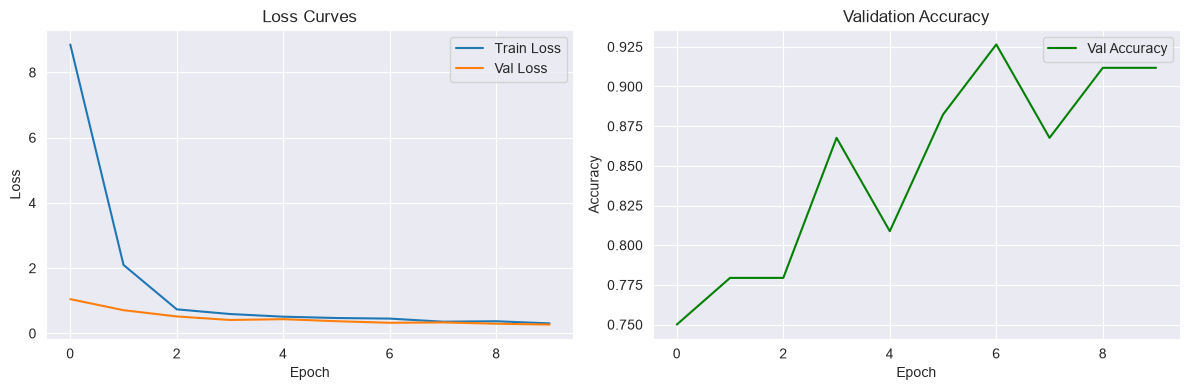

In [34]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Финальное тестирование модели

In [37]:
model.load_state_dict(torch.load("models/glaucoma_final.pth"))
model.eval()

test_loss, test_acc = validate(model, test_loader, loss_f)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")
print(f"Precision:            {precision:.4f}")
print(f"F1 Score:             {f1:.4f}")

print(classification_report(
    all_labels,
    all_preds,
    target_names=["GON- (Normal)", "GON+ (Glaucoma)"],
    digits=4
))

C:\Users\Aidarchik\Glaucoma-Detection-Using-CNN-PyTorch\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Loss: 0.2856
Test Accuracy: 0.8601
Sensitivity (Recall): 0.9592
Specificity:          0.6444
Precision:            0.8545
F1 Score:             0.9038
                 precision    recall  f1-score   support

  GON- (Normal)     0.8788    0.6444    0.7436        45
GON+ (Glaucoma)     0.8545    0.9592    0.9038        98

       accuracy                         0.8601       143
      macro avg     0.8667    0.8018    0.8237       143
   weighted avg     0.8622    0.8601    0.8534       143



## Итог

Модель показала высокую чувствительность (95.9%), что делает её надёжным инструментом скрининга глаукомы — модель почти не пропускает больных. Умеренная специфичность (64.4%) допустима на этапе первичной диагностики, так как ложноположительные результаты приведут лишь к дополнительному обследованию здоровых пациентов. Общая точность 86.0% и F1-мера 90.4% подтверждают стабильность модели.